Задание 1 (2 балла)
1. Скачать данные по ссылке https://www.kaggle.com/datasets/stealthtechnologies/predict-the-age-of-a-fossil;

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')

2. Построить регрессионную модель, предсказывающую возраст ископаемого с значением R-квадрат не ниже 0,8;

2.1. Целевая переменная 'age'

In [ ]:
target = 'age'

2.2. Определение чиловых столбцов и категориальных признаков

In [ ]:
features = train.select_dtypes(include=np.number).columns.tolist()
if target in features:
    features.remove(target)
    
cat_cols = train.select_dtypes(include=['object', 'category']).columns.tolist()

2.3. Обработка категориальных признаков (избежать мультиколлинеарности)

In [ ]:
for col in cat_cols:
    train = pd.concat([train, pd.get_dummies(train[col], prefix=col, drop_first=True)], axis=1)
    test = pd.concat([test, pd.get_dummies(test[col], prefix=col, drop_first=True)], axis=1)
    features.extend([c for c in train.columns if c.startswith(col + '_')])

2.4 Формирование матрицы признаков (x) и целевой переменной (y)

In [ ]:
X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

2.5 Обработка пропусков, масштабирование признаков

In [ ]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

2.6 Базовая линейная регрессия (оцениваем качество)

In [ ]:
model = LinearRegression()
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f'Linear Regression: R2={r2:.4f}, RMSE={rmse:.2f}, MAE={mae:.2f}')

Linear Regression: R2=0.9858, RMSE=1858.60, MAE=1426.62

2.7 Если меньше, то улучшаем (признаки 2-й степени, берем оптимальное количество признаков, пересчитываем, финальная проверка)

In [ ]:
if r2 < 0.8:
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_p = poly.fit_transform(X_train_s)
    X_test_p = poly.transform(X_test_s)
    
    k = min(50, X_train_p.shape[1])
    selector = SelectKBest(f_regression, k=k)
    X_train_sel = selector.fit_transform(X_train_p, y_train)
    X_test_sel = selector.transform(X_test_p)
    
    model = LinearRegression()
    model.fit(X_train_sel, y_train)
    y_pred = model.predict(X_test_sel)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    print(f'Polynomial Regression: R2={r2:.4f}, RMSE={rmse:.2f}, MAE={mae:.2f}')
    
print(f'\nR2: {r2:.4f}')
if r2 >= 0.8:
    print('ОК')

R2: 0.9858

3. Сгенерировать 10 значений для независимых переменных и на основании полученной модели определить возраст ископаемого;

3.1 Масштабируем данные

In [ ]:
np.random.seed(42)
new_data = pd.DataFrame()
for col in features:
    mn, mx = train[col].min(), train[col].max()
    new_data[col] = np.random.uniform(mn, mx, 10)

new_data_s = scaler.transform(new_data)
if r2 < 0.8 or 'poly' in locals():
    try:
        new_data_p = poly.transform(new_data_s)
        new_data_f = selector.transform(new_data_p)
        preds = model.predict(new_data_f)
    except:
        preds = model.predict(new_data_s)
else:
    preds = model.predict(new_data_s)

3.2  Предсказания возраста для 10 новых наблюдений (отображение)

In [ ]:
print('\nПредсказания для 10 новых наблюдений:')
for i, p in enumerate(preds, 1):
    print(f'{i}. Возраст: {p:.0f} лет')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Фактический')
plt.ylabel('Предсказанный')
plt.title(f'R2 = {r2:.4f}')

plt.subplot(1, 2, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Предсказанный')
plt.ylabel('Остатки')
plt.title('Остатки')

plt.tight_layout()
plt.show()

Предсказания для 10 новых наблюдений:
1. Возраст: 38500 лет
2. Возраст: 75764 лет
3. Возраст: 59622 лет
4. Возраст: 71855 лет
5. Возраст: 31193 лет
6. Возраст: 33704 лет
7. Возраст: 73 лет
8. Возраст: 67231 лет
9. Возраст: 61827 лет
10. Возраст: 55844 лет

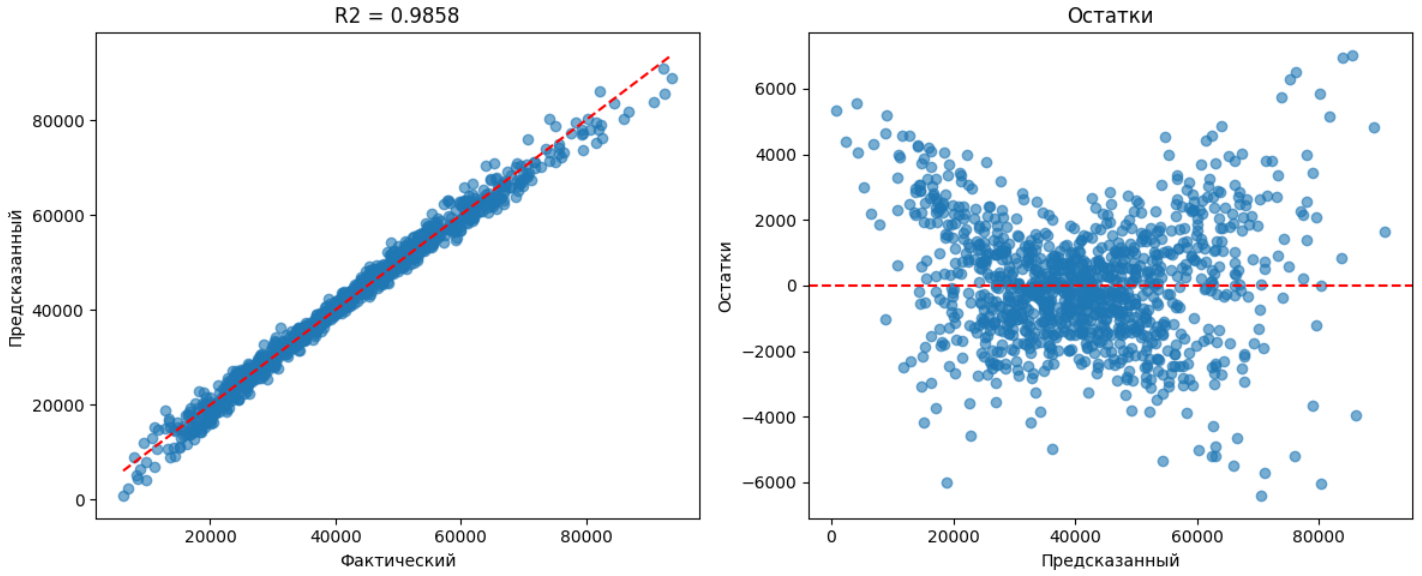

Задание 2 (2 балла)
1. Скачать данные по ссылке https://www.kaggle.com/datasets/martaarroyo/palmer-penguins-for-binary-classification;

1.1 Убираем пустые строки

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('penguins_binary_classification.csv')
df = df.dropna()

2. Построить модель логистической регрессии по столбцу species;

2.1 Кодирование целевой переменной, выбор признаков и разделение данных

In [ ]:
le = LabelEncoder()
df['species_enc'] = le.fit_transform(df['species'])

features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df[features]
y = df['species_enc']

2.2 Масштабирование признаков

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

2.3 Модель логистической регрессии

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

2.4 Оценка качества модели, матрица ошибок

In [ ]:
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {metrics.precision_score(y_test, y_pred):.4f}")
print(f"Recall: {metrics.recall_score(y_test, y_pred):.4f}")
print(f"F1: {metrics.f1_score(y_test, y_pred):.4f}")

print("\nМатрица ошибок:")
print(metrics.confusion_matrix(y_test, y_pred))

Accuracy: 1.0000

Precision: 1.0000

Recall: 1.0000

F1: 1.0000

Матрица ошибок:

[[30  0]

 [ 0 25]]

3. Визуализировать полученное разделение данных;

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['blue' if x == 0 else 'red' for x in df['species_enc']]
plt.scatter(df['bill_length_mm'], df['bill_depth_mm'], c=colors, alpha=0.5, edgecolors='k', s=20)
plt.xlabel('Длина клюва (мм)')
plt.ylabel('Глубина клюва (мм)')
plt.title('Визуализация разделения видов')

plt.subplot(1, 2, 2)
plt.scatter(df['flipper_length_mm'], df['body_mass_g'], c=colors, alpha=0.5, edgecolors='k', s=20)
plt.xlabel('Длина плавника (мм)')
plt.ylabel('Масса тела (г)')

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
coef_df = pd.DataFrame({'Признак': features, 'Коэфф': model.coef_[0]})
plt.barh(coef_df['Признак'], coef_df['Коэфф'], color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Значение коэффициента')
plt.title('Важность признаков')
plt.tight_layout()
plt.show()

print("\nКоэффициенты модели:")
print(f"Intercept: {model.intercept_[0]:.4f}")
for feat, coef in zip(features, model.coef_[0]):
    print(f"{feat}: {coef:.4f}")

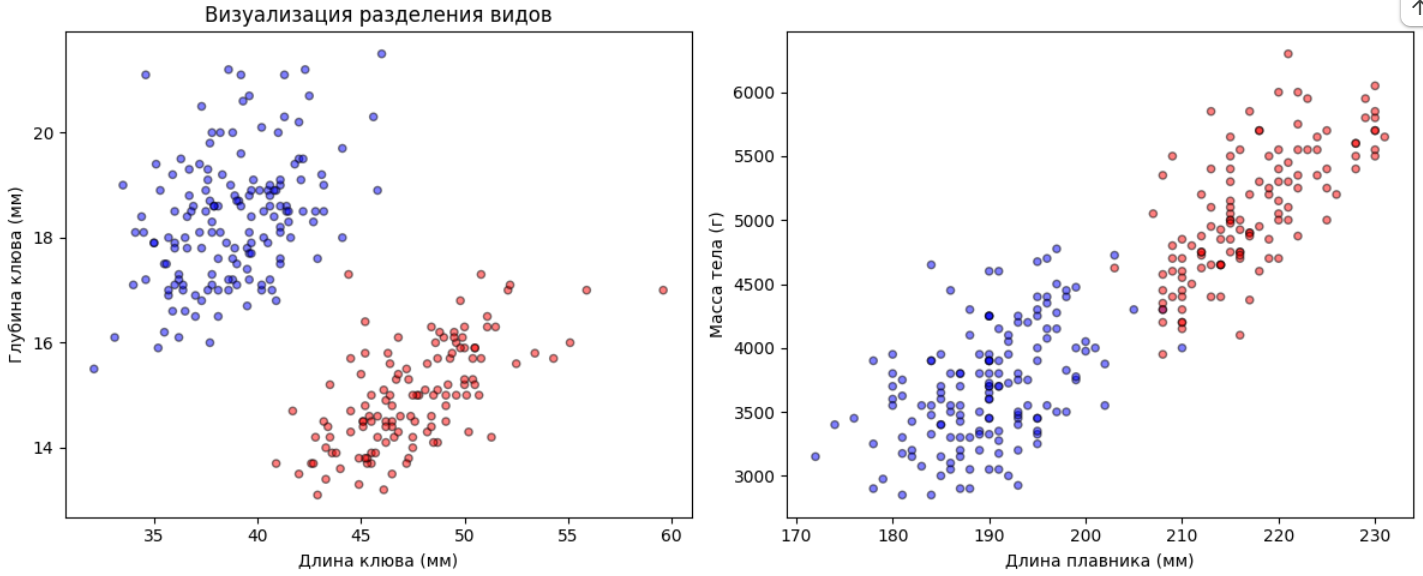

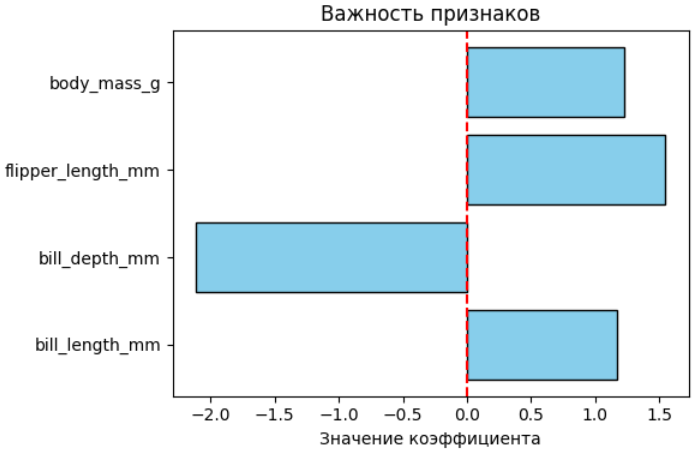

Коэффициенты модели:
- Intercept: -0.8746
- bill_length_mm: 1.1669
- ill_depth_mm: -2.1112
- flipper_length_mm: 1.5479
- body_mass_g: 1.2232

Задание* (4 балла)
1. Скачать данные по ссылке https://www.kaggle.com/datasets/yasserh/song-popularity-dataset

1.1 Определение списка признаков

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import metrics
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('song_data.csv')
target = 'song_popularity'
features = [c for c in df.select_dtypes(include=np.number).columns if c != target]

1.2 Подготовка матрицы признаков и целевой переменной

In [ ]:
X = df[features].copy()
y = df[target].copy()

2. Проверить данные на мультиколлинеарность: вывести матрицу корреляции и рассчитать VIF;

In [ ]:
print("Матрица корреляций:")
corr = X.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляция признаков')
plt.show()

Матрица корреляций:

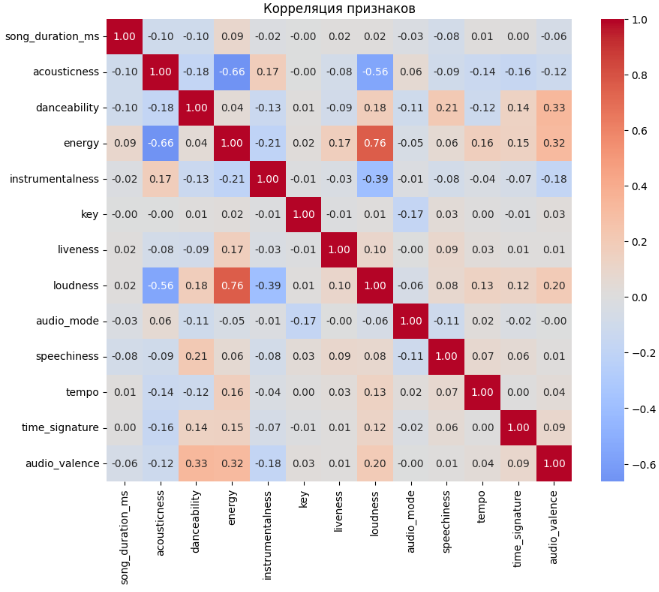

In [ ]:
print("\nПары с |r| > 0.7:")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.7:
            print(f"{corr.columns[i]} - {corr.columns[j]}: {corr.iloc[i, j]:.3f}")

Пары с |r| > 0.7:
energy - loudness: 0.756

In [ ]:
X_const = add_constant(X)
vif = pd.DataFrame()
vif["Feature"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
vif = vif[vif["Feature"] != "const"]

print("\nVIF значения:")
print(vif.round(2).to_string(index=False))

VIF значения:
| Feature            | VIF  |
|--------------------|------|
| song_duration_ms   | 1.05 |
| acousticness       | 1.98 |
| danceability       | 1.43 |
| energy             | 3.73 |
| instrumentalness   | 1.25 |
| key                | 1.03 |
| liveness           | 1.05 |
| loudness           | 2.94 |
| audio_mode         | 1.06 |
| speechiness        | 1.10 |
| tempo              | 1.06 |
| time_signature     | 1.05 |
| audio_valence      | 1.39 |

In [ ]:
plt.figure(figsize=(8, 6))
plt.barh(vif["Feature"], vif["VIF"], color=['red' if v > 10 else 'skyblue' for v in vif["VIF"]])
plt.axvline(10, color='red', linestyle='--')
plt.xlabel('VIF')
plt.title('Проверка на мультиколлинеарность')
plt.tight_layout()
plt.show()

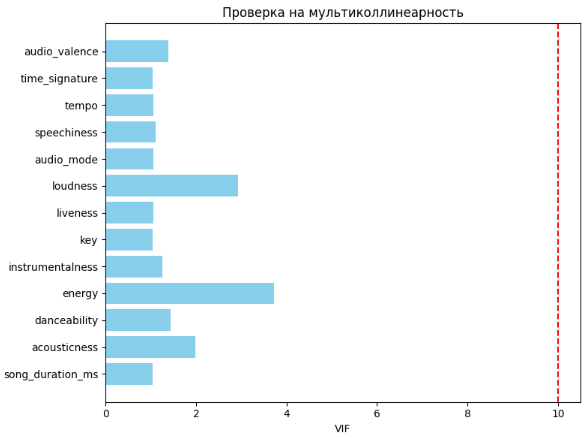

3. Построить регрессионные модели с зависимой переменной song_popularity (например, можно взять следующие модели: множественная линейная регрессия, ридж-регрессия, случайный лес. Подробнее: https://scikit-learn.org/stable/);

3.1 Масштабирование и разделение модели

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

3.2 Обучение и оценка моделей (базовая линейная регрессия, линейная регрессия с L2-регуляризацией, ансамбль деревьев)

In [ ]:
models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = metrics.r2_score(y_test, y_pred)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    mae = metrics.mean_absolute_error(y_test, y_pred)
    cv = cross_val_score(model, X_scaled, y, cv=3, scoring='r2').mean()
    
    results.append({'Model': name, 'R2_test': round(r2, 3), 'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'CV_R2': round(cv, 3)})
    print(f"{name}: R2={r2:.3f}, RMSE={rmse:.2f}, MAE={mae:.2f}, CV={cv:.3f}")

Linear: R2=0.042, RMSE=21.49, MAE=17.06, CV=0.019

Ridge: R2=0.042, RMSE=21.49, MAE=17.06, CV=0.019

RandomForest: R2=0.225, RMSE=19.33, MAE=15.25, CV=0.178

4. Сравнить метрики качества регрессионных моделей, выбрать лучшую, сделать выводы.

In [ ]:
res_df = pd.DataFrame(results).sort_values('R2_test', ascending=False)
print("\nСравнение моделей:")
print(res_df.to_string(index=False))

best_name = res_df.iloc[0]['Model']
best_model = models[best_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_best, alpha=0.4, edgecolors='k', s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Фактические')
plt.ylabel('Предсказанные')
plt.title(f'{best_name}: R2 = {res_df.iloc[0]["R2_test"]:.3f}')

plt.subplot(1, 2, 2)
if best_name == 'RandomForest':
    imp = pd.DataFrame({'feat': features, 'imp': best_model.feature_importances_}).sort_values('imp', ascending=False).head(10)
    plt.barh(imp['feat'], imp['imp'])
    plt.xlabel('Важность')
    plt.title('Топ-10 признаков (Random Forest)')
plt.tight_layout()
plt.show()

print(f"\nЛучшая модель: {best_name}")
print(f"R2 на тесте: {res_df.iloc[0]['R2_test']}")
print(f"RMSE: {res_df.iloc[0]['RMSE']}, MAE: {res_df.iloc[0]['MAE']}")

if vif['VIF'].max() > 10:
    print("\n VIF > 10 — возможна мультиколлинеарность")
else:
    print("\n Мультиколлинеарность ОК")

Сравнение моделей:
|       Model  | R2_test | RMSE | MAE | CV_R2|
|--------------|---------|------|------|----------|
| RandomForest |   0.225 |19.33 |15.25 | 0.178|
|       Linear |   0.042 | 21.49 |17.06 | 0.019|
|        Ridge |  0.042  |21.49 |17.06  |0.019|

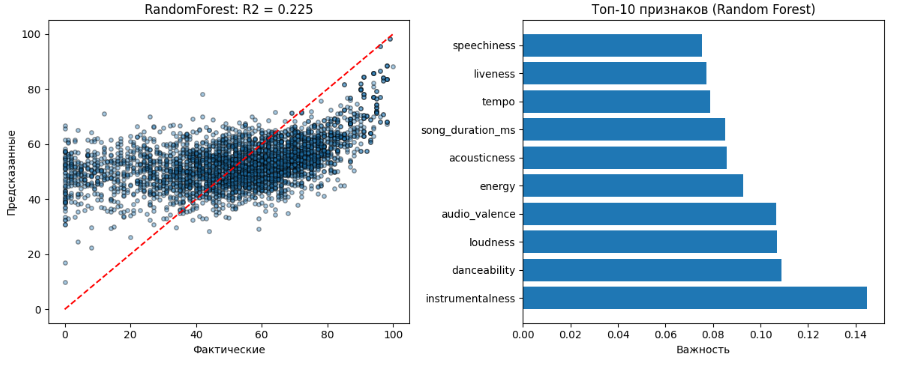

Лучшая модель: RandomForest

R2 на тесте: 0.225

RMSE: 19.33, MAE: 15.25

 Мультиколлинеарность ОК